In [3]:
import sqlite3
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import plot_roc_curve
from sklearn.model_selection import train_test_split, GridSearchCV      
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.gaussian_process import GaussianProcessClassifier  
from sklearn.gaussian_process.kernels import RBF  
from sklearn.svm import LinearSVC 
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer

In [4]:
os.getcwd()

'C:\\Users\\Tom\\Documents\\Project working directory\\Coursework\\Python files'

In [5]:
os.chdir('~\\Project working directory\\Coursework\\Python files')

FileNotFoundError: [WinError 3] The system cannot find the path specified: '~\\Project working directory\\Coursework\\Python files'

# Creating Database

In [6]:
try:
    os.remove('../Python files/py_airline5.db')
except OSError:
    pass

conn = sqlite3.connect('../Python files/py_+airline5.db')

# Creating table using airline data from 2001 to 2002

In [7]:
c = conn.cursor()

In [8]:
c.execute('''
CREATE TABLE arrived (
  Year int,
  Month int,
  DayofMonth int,
  DayOfWeek int,
  DepTime  int,
  CRSDepTime int,
  ArrTime int,
  CRSArrTime int,
  UniqueCarrier varchar(5),
  FlightNum int,
  TailNum varchar(8),
  ActualElapsedTime int,
  CRSElapsedTime int,
  AirTime int,
  ArrDelay int,
  DepDelay int,
  Origin varchar(3),
  Dest varchar(3),
  Distance int,
  TaxiIn int,
  TaxiOut int,
  Cancelled int,
  CancellationCode varchar(1),
  Diverted varchar(1),
  CarrierDelay int,
  WeatherDelay int,
  NASDelay int,
  SecurityDelay int,
  LateAircraftDelay int
)
''')

conn.commit()

In [9]:
for year in range(2001, 2002):
    print('Processing: ', year)
    arrived1 = pd.read_csv("../Python files/"+str(year)+".csv.bz2", encoding='latin-1')    
    arrived1.to_sql('arrived1', con = conn, if_exists = 'append', index = False)
for year in range(2002, 2003):
    print('Processing: ', year)
    arrived2 = pd.read_csv("../Python files/"+str(year)+".csv.bz2", encoding='latin-1')    
    arrived2.to_sql('arrived2', con = conn, if_exists = 'append', index = False)
conn.commit()

Processing:  2001
Processing:  2002


# Create dataframe

In [18]:
df1 = c.execute('''
SELECT Year, Month, DayOfWeek, DepDelay, Cancelled, Diverted, 
ActualElapsedTime, CRSElapsedTime, AirTime, Distance, TaxiIn, TaxiOut
 FROM arrived1
 WHERE Year IS NOT 2003
             ''').fetchall()
df2 = c.execute('''
SELECT Year, Month, DayOfWeek, DepDelay, Cancelled, Diverted, 
ActualElapsedTime, CRSElapsedTime, AirTime, Distance, TaxiIn, TaxiOut
 FROM arrived2
 WHERE Year IS NOT 2003
             ''').fetchall()

dt1 = pd.DataFrame(df1) 
dt2 = pd.DataFrame(df2)
dt3 = pd.concat([dt1, dt2])
dt3.columns = ['Year', 'Month','Weekday', 'DepDelay', 'Cancelled', 'Diverted', 
'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'Distance', 'TaxiIn', 'TaxiOut']

In [40]:
#Cleaning dataset
dt3.replace([np.inf, -np.inf], np.nan, inplace=True)
dt3.fillna(0, inplace=True)
#Generating sample size
df3 = dt3.sample(100000)

In [41]:
#Add a new feature Delayed 
df3['Delayed'] = np.where(df3['DepDelay']>0, 1, 0)
df3['Diverted'] = df3['Diverted'].astype('int')
from collections import Counter
df3.nunique()

Year                    2
Month                  12
Weekday                 7
DepDelay              351
Cancelled               2
Diverted                2
ActualElapsedTime     501
CRSElapsedTime        462
AirTime               475
Distance             1132
TaxiIn                105
TaxiOut               175
Delayed                 2
dtype: int64

In [42]:
#Pre-processing stage, defining X and Y for train set
features = ['Year', 'Month','Weekday', 'Cancelled', 'Diverted', 
'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'Distance', 'TaxiIn', 'TaxiOut']
X = df3[features].copy()
y = np.array(df3['Delayed'])

In [43]:
numerical_features = ['ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'Distance', 'TaxiIn', 'TaxiOut']

# Applying SimpleImputer, StandardScaler and MinMaxScaler into a pipeline
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler()),
    ('minmax', MinMaxScaler())])

categorical_features = ['Year', 'Month','Weekday', 'Cancelled', 'Diverted']

# Applying SimpleImputer and then OneHotEncoder into another pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

data_transformer = ColumnTransformer(
    transformers=[
        ('numerical', numerical_transformer, numerical_features),
        ('categorical', categorical_transformer, categorical_features)]) 

In [44]:
#Creating test and train sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1)


In [45]:
#Setting parameters
param_grid = {
    'data_transformer__numerical__imputer__strategy': ['mean', 'median'],
    'data_transformer__categorical__imputer__strategy': ['constant','most_frequent']
}


In [46]:
#Logistic regression
pipe_lr = Pipeline(steps=[('data_transformer', data_transformer),
                          ('pipe_lr', LogisticRegression(max_iter=10000, penalty='none'))]) #penalty='l2' is default

grid_lr = GridSearchCV(pipe_lr, param_grid=param_grid)
grid_lr.fit(X_train, y_train);

In [47]:
#Gradient Boosting
pipe_gdb = Pipeline(steps=[('data_transformer', data_transformer),
       ('pipe_gdb',GradientBoostingClassifier(random_state=2))])

grid_gdb = GridSearchCV(pipe_gdb, param_grid=param_grid)
grid_gdb.fit(X_train, y_train);

In [48]:
# Classification tree
pipe_tree = Pipeline(steps=[('data_transformer', data_transformer),
                           ('pipe_tree', DecisionTreeClassifier(random_state=0))])
grid_tree = GridSearchCV(pipe_tree, param_grid=param_grid)
grid_tree.fit(X_train, y_train);

In [49]:
# Random forest
pipe_rf = Pipeline(steps=[('data_transformer', data_transformer),
                           ('pipe_rf', RandomForestClassifier(random_state=0))])
grid_rf = GridSearchCV(pipe_rf, param_grid=param_grid)
grid_rf.fit(X_train, y_train);

In [50]:
# Support vector machines
pipe_svm = Pipeline(steps=[('data_transformer', data_transformer),
                           ('pipe_svm',  LinearSVC(random_state=0, max_iter=10000, tol=0.01))])
grid_svm = GridSearchCV(pipe_svm, param_grid=param_grid)
grid_svm.fit(X_train, y_train);

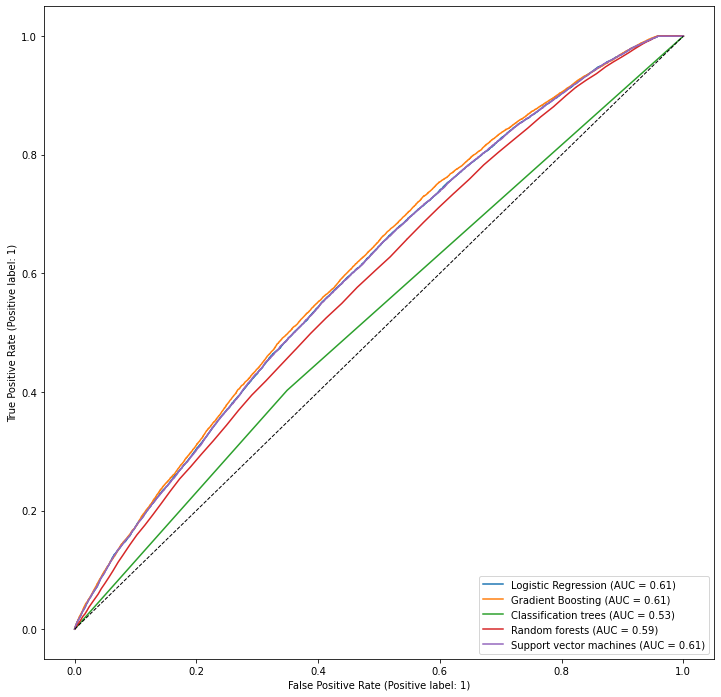

In [51]:
ax, fig = plt.subplots(figsize=(12,12))
ax = plt.gca()

plot_roc_curve(grid_lr, X_test, y_test, ax=ax, name='Logistic Regression')
plot_roc_curve(grid_gdb, X_test, y_test, ax=ax, name='Gradient Boosting')
plot_roc_curve(grid_tree, X_test, y_test, ax=ax, name='Classification trees')
plot_roc_curve(grid_rf, X_test, y_test, ax=ax, name='Random forests')
plot_roc_curve(grid_svm, X_test, y_test, ax=ax, name='Support vector machines')
plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--')
plt.show()

In [53]:
conn.close()